# Lance 数据集可视化 (Plotly Standalone)

完全独立的 notebook，使用 Plotly 进行交互式 3D 可视化

**功能**:
- 从 Lance 数据集加载轨迹数据
- 生成 MANO mesh 和 joints
- 可视化 URDF 机器人模型
- 可视化物体 mesh
- 显示同步视频流
- 交互式帧控制和播放

## 1. 环境初始化

In [1]:
import numpy as np
import lance
from pathlib import Path
from scipy.spatial.transform import Rotation
import torch
from manotorch.manolayer import ManoLayer
import pickle
import os
import cv2
import base64
from io import BytesIO
from PIL import Image

# Plotly 和 widgets
import plotly.graph_objects as go
from plotly.graph_objs import FigureWidget
import plotly.offline as pyo
from ipywidgets import (
    Dropdown, IntSlider, VBox, HBox, Output, 
    Layout, Button, Checkbox, HTML as WidgetHTML,
    SelectMultiple
)
from IPython.display import display, HTML

# Pinocchio (可选 - URDF 支持)
PINOCCHIO_AVAILABLE = False
try:
    import pinocchio as pin
    from lxml import etree
    PINOCCHIO_AVAILABLE = True
    print("✓ Pinocchio 已加载 - URDF 可视化功能可用")
except ImportError:
    print("⚠️  Pinocchio 未安装 - URDF 功能将被禁用")

# Trimesh (物体 mesh)
import trimesh

# 获取项目根目录（notebook 在 notebook/ 子目录下）
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
print(f"项目根目录: {PROJECT_ROOT}")

pyo.init_notebook_mode(connected=True)
print("✓ 环境初始化完成")

✓ Pinocchio 已加载 - URDF 可视化功能可用
项目根目录: /mnt/user-home/czk/projects/lance_viz_new


✓ 环境初始化完成


## 2. MANO 顶点生成

In [2]:
def generate_mano_vertices(
    mano_model_path: str,
    hand: str,
    beta: np.ndarray,
    hand_pose: np.ndarray,
    T: int
) -> np.ndarray:
    """生成 MANO 顶点（模板空间）"""
    # 使用绝对路径作为 mano_assets_root
    mano_assets_root = str(PROJECT_ROOT / "assets")
    
    mano_layer = ManoLayer(
        mano_assets_root=mano_assets_root,
        use_pca=False,
        flat_hand_mean=True,
        side=hand
    )
    
    beta_batch = torch.from_numpy(beta).float().unsqueeze(0).repeat(T, 1)
    hand_pose_t = torch.from_numpy(hand_pose).float()
    
    with torch.no_grad():
        output = mano_layer(hand_pose_t, beta_batch)
        vertices_template = output.verts.cpu().numpy()
    
    return vertices_template.astype(np.float32)


def load_mano_faces(mano_model_path: str) -> np.ndarray:
    """从 MANO pkl 文件加载 faces"""
    with open(mano_model_path, 'rb') as f:
        mano_data = pickle.load(f, encoding='latin1')
    return mano_data['f']


def transform_mano_to_world(vertices, joints, global_orient, transl):
    """将 MANO 从模板空间转换到世界空间"""
    rot_global = Rotation.from_rotvec(global_orient)
    rot_matrix = rot_global.as_matrix()
    
    vertices_world = (rot_matrix @ vertices.T).T + transl
    joints_world = (rot_matrix @ joints.T).T + transl
    
    return vertices_world, joints_world

print("✓ MANO 函数已定义")

✓ MANO 函数已定义


## 3. 视频处理函数

In [3]:
def get_video_blobs(lance_row):
    """获取视频 blobs 数据"""
    video = lance_row.get('video', [])
    video_depth = lance_row.get('video_depth', [])
    
    return {
        'video': video,
        'video_depth': video_depth,
        'num_cameras': len(video) if video else 0
    }

def decode_video_frame(video_blobs, cam_idx, frame_idx, stream='color'):
    """解码并获取指定帧
    
    Args:
        video_blobs: 视频 blobs 字典
        cam_idx: 摄像头索引
        frame_idx: 帧索引
        stream: 'color' 或 'depth'
    
    Returns:
        RGB 图像数组 (H, W, 3)
    """
    if cam_idx >= video_blobs['num_cameras']:
        return None
    
    if stream == 'color':
        if video_blobs['video']:
            color_blobs = video_blobs['video'][cam_idx].get('color', [])
            if frame_idx < len(color_blobs):
                frame = cv2.imdecode(
                    np.frombuffer(color_blobs[frame_idx], np.uint8),
                    cv2.IMREAD_COLOR
                )
                return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    else:  # depth
        if video_blobs['video_depth']:
            depth_blobs = video_blobs['video_depth'][cam_idx].get('depth', [])
            if frame_idx < len(depth_blobs):
                frame = cv2.imdecode(
                    np.frombuffer(depth_blobs[frame_idx], np.uint8),
                    cv2.IMREAD_UNCHANGED
                )
                # 深度图彩色化
                depth_norm = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX)
                depth_color = cv2.applyColorMap(depth_norm.astype(np.uint8), cv2.COLORMAP_JET)
                return cv2.cvtColor(depth_color, cv2.COLOR_BGR2RGB)
    
    return None

def frame_to_base64(frame):
    """将帧转换为 base64 编码用于 HTML 显示"""
    if frame is None:
        return None
    img = Image.fromarray(frame)
    buffer = BytesIO()
    img.save(buffer, format='PNG')
    buffer.seek(0)
    return f'data:image/png;base64,{base64.b64encode(buffer.read()).decode()}'

print("✓ 视频处理函数已定义")

✓ 视频处理函数已定义


## 4. URDF Helper

In [4]:
class URDFHelper:
    """URDF 加载和运动学计算辅助类"""
    
    def __init__(self, urdf_path: str = None):
        self.urdf_path = urdf_path
        self.model = None
        self.data = None
        self.skeleton = None
        self.mesh_pairs = None
        self.mesh_map = {}
        
        if urdf_path and PINOCCHIO_AVAILABLE:
            self.load_urdf(urdf_path)
    
    def load_urdf(self, urdf_path: str):
        """使用 Pinocchio 加载 URDF 模型"""
        if not PINOCCHIO_AVAILABLE:
            print("⚠️  Pinocchio 未安装，无法加载 URDF")
            return False
        
        urdf_path = Path(urdf_path)
        if not urdf_path.exists():
            print(f"⚠️  URDF 文件不存在: {urdf_path}")
            return False
        
        try:
            self.urdf_path = str(urdf_path)
            self.model = pin.buildModelFromUrdf(self.urdf_path)
            self.data = self.model.createData()
            self.skeleton = self._parse_skeleton()
            
            # 加载 mesh 数据
            self.mesh_map = self._parse_urdf_visual_meshes()
            self.mesh_pairs = self._load_urdf_meshes()
            
            print(f"✓ URDF 加载成功: {self.model.nq} DOFs, {self.model.njoints} joints")
            if self.mesh_pairs:
                print(f"  ✓ 加载了 {len(self.mesh_pairs)} 个 link meshes")
            return True
        except Exception as e:
            print(f"❌ URDF 加载失败: {e}")
            return False
    
    def _parse_skeleton(self):
        """解析 URDF 骨架连接关系"""
        if not self.model:
            return []
        
        connections = []
        for i in range(1, self.model.njoints):
            parent_id = self.model.parents[i]
            if parent_id > 0:
                connections.append((parent_id - 1, i - 1))
        
        return connections
    
    def _parse_urdf_visual_meshes(self):
        """解析 URDF XML 提取 link-to-mesh 映射"""
        if not self.urdf_path:
            return {}
        
        tree = etree.parse(str(self.urdf_path))
        root = tree.getroot()
        
        mesh_map = {}
        for link in root.findall('link'):
            link_name = link.get('name')
            visual = link.find('visual')
            if visual is not None:
                geometry = visual.find('geometry')
                if geometry is not None:
                    mesh_elem = geometry.find('mesh')
                    if mesh_elem is not None:
                        mesh_filename = mesh_elem.get('filename')
                        mesh_map[link_name] = mesh_filename
        
        return mesh_map
    
    def _load_urdf_meshes(self):
        """加载 URDF meshes 并创建与 Pinocchio frames 的映射"""
        if not self.mesh_map:
            return None
        
        urdf_dir = Path(self.urdf_path).parent
        mesh_frame_pairs = []
        
        for link_name, mesh_filename in self.mesh_map.items():
            if mesh_filename.startswith('meshes/'):
                mesh_filename = mesh_filename[7:]
            
            mesh_path = urdf_dir / "meshes" / mesh_filename
            
            if not mesh_path.exists():
                continue
            
            try:
                mesh = trimesh.load(str(mesh_path))
                
                link_frame_idx = None
                for i in range(len(self.model.frames)):
                    if self.model.frames[i].name == link_name:
                        link_frame_idx = i
                        break
                
                if link_frame_idx is not None:
                    mesh_data = {
                        'vertices': np.asarray(mesh.vertices, dtype=np.float32),
                        'faces': np.asarray(mesh.faces, dtype=np.int32),
                    }
                    mesh_frame_pairs.append((mesh_data, link_frame_idx))
            
            except Exception as e:
                print(f"  ⚠️  无法加载 mesh {mesh_path}: {e}")
        
        return mesh_frame_pairs if mesh_frame_pairs else None
    
    def forward_kinematics(self, q: np.ndarray):
        """计算前向运动学"""
        if not self.model or not self.data:
            return False
        
        try:
            pin.forwardKinematics(self.model, self.data, q)
            pin.updateFramePlacements(self.model, self.data)
            return True
        except Exception as e:
            print(f"⚠️  前向运动学计算失败: {e}")
            return False
    
    def extract_joint_positions(self) -> np.ndarray:
        """提取关节位置"""
        if not self.data:
            return None
        
        positions = []
        for i in range(1, self.model.njoints):
            pos = self.data.oMi[i].translation
            positions.append(pos)
        
        return np.array(positions)
    
    def get_transformed_meshes(self):
        """获取应用 FK 变换后的 meshes"""
        if not self.mesh_pairs or not self.data:
            return []
        
        transformed_meshes = []
        for mesh_data, link_frame_idx in self.mesh_pairs:
            T = self.data.oMf[link_frame_idx].homogeneous
            
            vertices = mesh_data['vertices']
            vertices_homo = np.hstack([vertices, np.ones((len(vertices), 1))])
            vertices_transformed = (T @ vertices_homo.T).T[:, :3]
            
            transformed_meshes.append({
                'vertices': vertices_transformed,
                'faces': mesh_data['faces']
            })
        
        return transformed_meshes
    
    def get_joint_names(self):
        """获取关节名称列表"""
        if not self.model:
            return []
        return [self.model.names[i] for i in range(1, self.model.njoints)]

print("✓ URDFHelper 类已定义")

✓ URDFHelper 类已定义


## 5. 加载 Lance 数据集

In [5]:
# 配置路径（使用绝对路径）
LANCE_PATH = str(PROJECT_ROOT / '/mnt/nas-222-project/mocap/releases/v0.5/trajectories_preprocessed.lance')
MANO_MODEL_PATH = str(PROJECT_ROOT / 'assets/models/MANO_RIGHT.pkl')
HAND = 'right'

# 加载数据集
print(f"加载 Lance 数据集: {LANCE_PATH}")
dataset = lance.dataset(LANCE_PATH)
total_rows = dataset.count_rows()
print(f"总轨迹数: {total_rows}")
print(f"列名: {dataset.schema.names}")

class OptimizedLanceLoader:
    """优化的 Lance 数据加载器，使用缓存和列选择"""
    
    def __init__(self, lance_dataset):
        self.dataset = lance_dataset
        self.total_rows = lance_dataset.count_rows()
        self._metadata_cache = {}
        self._video_cache = {}
        
    def get_trajectory_info(self, index):
        """获取指定轨迹的信息（只加载需要的列）"""
        if index not in self._metadata_cache:
            try:
                # 只加载需要的列，避免加载整个数据集
                row = self.dataset.take([index], columns=['index', 'trajectory_metadata'])
                index_data = row['index'][0].as_py()
                meta = row['trajectory_metadata'][0].as_py()
                
                self._metadata_cache[index] = {
                    'scene': index_data['scene'],
                    'operator': index_data['operator'],
                    'frames': meta['total_frames'],
                    'uuid': index_data['uuid'][:16],
                    'capMachine': index_data.get('capMachine', 'unknown')
                }
            except Exception as e:
                self._metadata_cache[index] = {
                    'scene': f'Error: {e}',
                    'operator': 'N/A',
                    'frames': 0,
                    'uuid': 'unknown',
                    'capMachine': 'unknown'
                }
        
        return self._metadata_cache[index]
    
    def load_trajectory_data(self, index):
        """加载完整的轨迹数据（只在需要时加载）"""
        try:
            print(f"加载轨迹索引: {index}")
            # 只加载需要的列
            row = self.dataset.take([index])
            lance_row = {
                key: row[key][0].as_py()
                for key in row.schema.names
            }
            
            # 显示信息
            info = self.get_trajectory_info(index)
            print(f"场景: {info['scene']}")
            print(f"操作员: {info['operator']}")
            print(f"帧数: {info['frames']}")
            
            return lance_row
        except Exception as e:
            print(f"❌ 加载轨迹失败: {e}")
            return None
    
    def get_video_blobs(self, index):
        """获取视频 blobs（缓存）"""
        if index not in self._video_cache:
            row = self.dataset.take([index], columns=['video', 'video_depth'])
            video = row['video'][0].as_py()
            video_depth = row['video_depth'][0].as_py()
            self._video_cache[index] = {
                'video': video,
                'video_depth': video_depth,
                'num_cameras': len(video),
            }
        return self._video_cache[index]
    
    def create_trajectory_options(self):
        """创建轨迹选项列表 - 显示所有索引"""
        options = []
        for i in range(self.total_rows):  # 显示所有轨迹
            info = self.get_trajectory_info(i)
            if info['frames'] > 0:
                label = f"{i:03d}: {info['scene']} ({info['operator']}) - {info['frames']}帧"
                options.append((label, i))
            else:
                label = f"{i:03d}: 不可用"
                options.append((label, i))
        
        return options

# 初始化优化加载器
loader = OptimizedLanceLoader(dataset)
print("✓ 优化加载器已初始化")

# 初始轨迹索引
TRAJECTORY_INDEX = 0
lance_row = loader.load_trajectory_data(TRAJECTORY_INDEX)

加载 Lance 数据集: /mnt/nas-222-project/mocap/releases/v0.5/trajectories_preprocessed.lance
总轨迹数: 12378
列名: ['index', 'trajectory_metadata', 'timestamp', 'hands', 'objects', 'video', 'video_depth', 'contact']
✓ 优化加载器已初始化
加载轨迹索引: 0
场景: banana_01
操作员: s02
帧数: 668


## 6. 转换数据格式

In [6]:
# 初始轨迹索引（已在 cell 10 中通过优化加载器加载）
# lance_row 已经通过 loader.load_trajectory_data(TRAJECTORY_INDEX) 加载

# 提取数据
hands = lance_row['hands'][0]
objects = lance_row['objects'][0]

# MANO shape 参数
mano_beta = np.array(
    lance_row['trajectory_metadata']['mano_hand_shapes'][0],
    dtype=np.float32
)

# 关节位置 (T, 63) -> (T, 21, 3)
mano_joint_pos = np.array(hands['mano_joint_pos'], dtype=np.float32)
T = mano_joint_pos.shape[0]
mano_joints = mano_joint_pos.reshape(T, 21, 3)

# MANO 参数
global_orient = np.array(hands['mano_global_rot_aa'], dtype=np.float32)
transl = np.array(hands['mano_global_pos'], dtype=np.float32)
hand_pose = np.array(hands['mano_hand_pose'], dtype=np.float32)

# 生成 MANO 顶点
print("\n生成 MANO 顶点...")
mano_vertices = generate_mano_vertices(
    MANO_MODEL_PATH, HAND, mano_beta, hand_pose, T
)
print(f"✓ MANO 顶点: {mano_vertices.shape}")

# 加载 MANO faces
mano_faces = load_mano_faces(MANO_MODEL_PATH)
print(f"✓ MANO faces: {mano_faces.shape}")

# URDF DOF
urdf_dof = np.array(hands['urdf_dof'], dtype=np.float32)

# 物体位姿
obj_pos = np.array(objects['pos'], dtype=np.float32)
obj_rot_aa = np.array(objects['rot_aa'], dtype=np.float32)

# 使用优化的视频加载器
video_blobs = loader.get_video_blobs(TRAJECTORY_INDEX)
print(f"✓ 视频数据: {video_blobs['num_cameras']} 个摄像头")


生成 MANO 顶点...
✓ MANO 顶点: (668, 778, 3)
✓ MANO faces: (1538, 3)


/tmp/ipykernel_2523277/2592969211.py:32: DeprecationWarning:

Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.



✓ 视频数据: 2 个摄像头


## 7. 加载资源

In [7]:
# 自动检测 URDF（使用绝对路径）
operator = lance_row['index']['operator']
urdf_path = PROJECT_ROOT / f"assets/operators/{operator}/mano_hand.urdf"
urdf_helper = None

if urdf_path.exists() and PINOCCHIO_AVAILABLE:
    urdf_helper = URDFHelper(str(urdf_path))
    if urdf_helper.model is None:
        urdf_helper = None
else:
    print("⚠️  URDF 不可用")

# 自动检测物体 mesh（使用绝对路径）
object_name = lance_row['trajectory_metadata']['object_names'][0]
object_mesh = None
object_paths = [
    PROJECT_ROOT / f"assets/objects/{object_name}.stl",
    PROJECT_ROOT / f"assets/objects/{object_name}/{object_name}.stl",
]

for obj_path in object_paths:
    if obj_path.exists():
        try:
            mesh = trimesh.load(str(obj_path))
            mesh.vertices = mesh.vertices * 0.001  # mm to m
            object_mesh = {
                'vertices': np.asarray(mesh.vertices, dtype=np.float32),
                'faces': np.asarray(mesh.faces, dtype=np.int32)
            }
            print(f"✓ 物体 mesh 已加载: {object_mesh['vertices'].shape}")
            break
        except Exception as e:
            print(f"⚠️  加载物体 mesh 失败: {e}")

if object_mesh is None:
    print("⚠️  物体 mesh 不可用")

✓ URDF 加载成功: 26 DOFs, 27 joints
  ✓ 加载了 16 个 link meshes
✓ 物体 mesh 已加载: (7866, 3)


## 8. Plotly 可视化函数

In [8]:
def initialize_figure():
    """初始化 Plotly FigureWidget"""
    fig = FigureWidget()
    
    # Trace 0: MANO mesh
    fig.add_trace(go.Mesh3d(
        x=[], y=[], z=[],
        i=[], j=[], k=[],
        color='lightblue',
        opacity=0.7,
        name='MANO Mesh',
        visible=True,
        hoverinfo='skip'
    ))
    
    # Trace 1: MANO joints
    fig.add_trace(go.Scatter3d(
        x=[], y=[], z=[],
        mode='markers',
        marker=dict(size=5, color='red', opacity=0.8),
        name='MANO Joints',
        text=[],
        hoverinfo='text',
        visible=False
    ))
    
    # Trace 2: URDF joints
    fig.add_trace(go.Scatter3d(
        x=[], y=[], z=[],
        mode='markers',
        marker=dict(size=6, color='purple', symbol='diamond', opacity=0.9),
        name='URDF Joints',
        text=[],
        hoverinfo='text',
        visible=False
    ))
    
    # Traces 3+: URDF meshes (预创建 25 个)
    for i in range(25):
        fig.add_trace(go.Mesh3d(
            x=[], y=[], z=[],
            i=[], j=[], k=[],
            color='#F5DEB3',
            opacity=0.7,
            name='URDF Mesh' if i == 0 else None,
            showlegend=(i == 0),
            visible=False,
            hoverinfo='skip'
        ))
    
    # Trace 28: Object mesh
    fig.add_trace(go.Mesh3d(
        x=[], y=[], z=[],
        i=[], j=[], k=[],
        color='#FFD700',
        opacity=0.8,
        name='Object',
        visible=True,
        hoverinfo='skip'
    ))
    
    # Trace 29: Origin axes (坐标轴)
    # 创建三个坐标轴：X(红), Y(绿), Z(蓝)
    axis_length = 0.1
    fig.add_trace(go.Scatter3d(
        x=[0, axis_length, None, 0, 0, None, 0, 0],
        y=[0, 0, None, 0, axis_length, None, 0, 0],
        z=[0, 0, None, 0, 0, None, 0, axis_length],
        mode='lines',
        line=dict(color=['red', 'red', 'red', 'green', 'green', 'green', 'blue', 'blue'], width=4),
        name='Origin',
        visible=False,
        hoverinfo='skip',
        showlegend=True
    ))
    
    # 布局
    fig.update_layout(
        title="Lance Visualization",
        scene=dict(
            xaxis=dict(title='X (m)'),
            yaxis=dict(title='Y (m)'),
            zaxis=dict(title='Z (m)'),
            aspectmode='data',
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.2),
                center=dict(x=0, y=0, z=0)
            )
        ),
        height=600,
        template='plotly_dark',
        showlegend=True,
        margin=dict(l=0, r=0, t=50, b=0),
        uirevision='constant'
    )
    
    return fig


def update_figure(
    fig, frame_idx,
    show_mano_mesh=True,
    show_mano_joints=False,
    show_urdf_joints=False,
    show_urdf_mesh=False,
    show_object=True,
    show_origin=False
):
    """更新 figure 数据"""
    with fig.batch_update():
        # MANO mesh
        if show_mano_mesh:
            vertices_world, _ = transform_mano_to_world(
                mano_vertices[frame_idx],
                mano_joints[frame_idx],
                global_orient[frame_idx],
                transl[frame_idx]
            )
            fig.data[0].x = vertices_world[:, 0].tolist()
            fig.data[0].y = vertices_world[:, 1].tolist()
            fig.data[0].z = vertices_world[:, 2].tolist()
            fig.data[0].i = mano_faces[:, 0].tolist()
            fig.data[0].j = mano_faces[:, 1].tolist()
            fig.data[0].k = mano_faces[:, 2].tolist()
            fig.data[0].visible = True
        else:
            fig.data[0].visible = False
        
        # MANO joints
        if show_mano_joints:
            _, joints_world = transform_mano_to_world(
                mano_vertices[frame_idx],
                mano_joints[frame_idx],
                global_orient[frame_idx],
                transl[frame_idx]
            )
            fig.data[1].x = joints_world[:, 0].tolist()
            fig.data[1].y = joints_world[:, 1].tolist()
            fig.data[1].z = joints_world[:, 2].tolist()
            fig.data[1].text = [f'Joint {i}' for i in range(21)]
            fig.data[1].visible = True
        else:
            fig.data[1].visible = False
        
        # URDF
        if urdf_helper:
            urdf_helper.forward_kinematics(urdf_dof[frame_idx])
            
            # URDF joints
            if show_urdf_joints:
                urdf_joints = urdf_helper.extract_joint_positions()
                fig.data[2].x = urdf_joints[:, 0].tolist()
                fig.data[2].y = urdf_joints[:, 1].tolist()
                fig.data[2].z = urdf_joints[:, 2].tolist()
                joint_names = urdf_helper.get_joint_names()
                fig.data[2].text = [f'URDF {name}' for name in joint_names]
                fig.data[2].visible = True
            else:
                fig.data[2].visible = False
            
            # URDF meshes
            if show_urdf_mesh:
                transformed_meshes = urdf_helper.get_transformed_meshes()
                for i, mesh_data in enumerate(transformed_meshes):
                    trace_idx = 3 + i
                    vertices = mesh_data['vertices']
                    faces = mesh_data['faces']
                    fig.data[trace_idx].x = vertices[:, 0].tolist()
                    fig.data[trace_idx].y = vertices[:, 1].tolist()
                    fig.data[trace_idx].z = vertices[:, 2].tolist()
                    fig.data[trace_idx].i = faces[:, 0].tolist()
                    fig.data[trace_idx].j = faces[:, 1].tolist()
                    fig.data[trace_idx].k = faces[:, 2].tolist()
                    fig.data[trace_idx].visible = True
                
                for i in range(len(transformed_meshes), 25):
                    fig.data[3 + i].visible = False
            else:
                for i in range(25):
                    fig.data[3 + i].visible = False
        else:
            fig.data[2].visible = False
            for i in range(25):
                fig.data[3 + i].visible = False
        
        # Object (trace 28)
        if show_object and object_mesh:
            rot = Rotation.from_rotvec(obj_rot_aa[frame_idx])
            vertices = object_mesh['vertices'].copy()
            vertices = rot.apply(vertices) + obj_pos[frame_idx]
            faces = object_mesh['faces']
            
            fig.data[28].x = vertices[:, 0].tolist()
            fig.data[28].y = vertices[:, 1].tolist()
            fig.data[28].z = vertices[:, 2].tolist()
            fig.data[28].i = faces[:, 0].tolist()
            fig.data[28].j = faces[:, 1].tolist()
            fig.data[28].k = faces[:, 2].tolist()
            fig.data[28].visible = True
        else:
            fig.data[28].visible = False
        
        # Origin axes (trace 29)
        fig.data[29].visible = show_origin
        
        # 更新标题
        fig.layout.title.text = f"Scene: {lance_row['index']['scene']} | Frame {frame_idx}"

print("✓ Plotly 函数已定义")

✓ Plotly 函数已定义


In [9]:
# Curve 数据提取函数
def get_curve_options():
    """获取所有可绘制的曲线选项"""
    options = []
    
    # MANO global position (3D)
    options.extend([
        'mano.global_pos.x',
        'mano.global_pos.y',
        'mano.global_pos.z',
    ])
    
    # MANO global rotation (axis-angle, 3D)
    options.extend([
        'mano.global_rot_aa.x',
        'mano.global_rot_aa.y',
        'mano.global_rot_aa.z',
    ])
    
    # MANO joints positions (21 joints, 3D each)
    for joint_idx in range(21):
        options.extend([
            f'mano.joint[{joint_idx}].pos.x',
            f'mano.joint[{joint_idx}].pos.y',
            f'mano.joint[{joint_idx}].pos.z',
        ])
    
    # URDF DOF (26 DOF)
    if urdf_helper and urdf_helper.model:
        for dof_idx in range(urdf_helper.model.nq):
            options.append(f'urdf.dof[{dof_idx}]')
    
    # Object position (3D)
    options.extend([
        'object.pos.x',
        'object.pos.y',
        'object.pos.z',
    ])
    
    # Object rotation (axis-angle, 3D)
    options.extend([
        'object.rot_aa.x',
        'object.rot_aa.y',
        'object.rot_aa.z',
    ])
    
    return options

def get_curve_data(curve_name):
    """获取指定曲线的数据"""
    import re
    
    # MANO global position
    match = re.match(r'mano\.global_pos\.([xyz])', curve_name)
    if match:
        axis = match.group(1)
        axis_map = {'x': 0, 'y': 1, 'z': 2}
        return transl[:, axis_map[axis]]
    
    # MANO global rotation
    match = re.match(r'mano\.global_rot_aa\.([xyz])', curve_name)
    if match:
        axis = match.group(1)
        axis_map = {'x': 0, 'y': 1, 'z': 2}
        return global_orient[:, axis_map[axis]]
    
    # MANO joints
    match = re.match(r'mano\.joint\[(\d+)\]\.pos\.([xyz])', curve_name)
    if match:
        joint_idx = int(match.group(1))
        axis = match.group(2)
        axis_map = {'x': 0, 'y': 1, 'z': 2}
        if joint_idx < 21:
            return mano_joints[:, joint_idx, axis_map[axis]]
    
    # URDF DOF
    match = re.match(r'urdf\.dof\[(\d+)\]', curve_name)
    if match:
        dof_idx = int(match.group(1))
        if urdf_helper and dof_idx < urdf_dof.shape[1]:
            return urdf_dof[:, dof_idx]
    
    # Object position
    match = re.match(r'object\.pos\.([xyz])', curve_name)
    if match:
        axis = match.group(1)
        axis_map = {'x': 0, 'y': 1, 'z': 2}
        return obj_pos[:, axis_map[axis]]
    
    # Object rotation
    match = re.match(r'object\.rot_aa\.([xyz])', curve_name)
    if match:
        axis = match.group(1)
        axis_map = {'x': 0, 'y': 1, 'z': 2}
        return obj_rot_aa[:, axis_map[axis]]
    
    return None

def reload_trajectory_data(index):
    """使用优化的加载器重新加载指定轨迹的所有数据"""
    global lance_row, hands, objects, mano_beta, mano_joints, global_orient, transl, hand_pose, urdf_dof, obj_pos, obj_rot_aa, video_blobs, mano_vertices, T
    global urdf_helper, object_mesh
    
    try:
        # 使用优化的加载器
        new_lance_row = loader.load_trajectory_data(index)
        if new_lance_row is None:
            return False
            
        lance_row = new_lance_row
        
        # 提取数据
        hands = lance_row['hands'][0]
        objects = lance_row['objects'][0]
        
        # MANO shape 参数
        mano_beta = np.array(
            lance_row['trajectory_metadata']['mano_hand_shapes'][0],
            dtype=np.float32
        )
        
        # 关节位置 (T, 63) -> (T, 21, 3)
        mano_joint_pos = np.array(hands['mano_joint_pos'], dtype=np.float32)
        T = mano_joint_pos.shape[0]
        mano_joints = mano_joint_pos.reshape(T, 21, 3)
        
        # MANO 参数
        global_orient = np.array(hands['mano_global_rot_aa'], dtype=np.float32)
        transl = np.array(hands['mano_global_pos'], dtype=np.float32)
        hand_pose = np.array(hands['mano_hand_pose'], dtype=np.float32)
        
        # 生成 MANO 顶点
        print("重新生成 MANO 顶点...")
        mano_vertices = generate_mano_vertices(
            MANO_MODEL_PATH, HAND, mano_beta, hand_pose, T
        )
        
        # URDF DOF
        urdf_dof = np.array(hands['urdf_dof'], dtype=np.float32)
        
        # 物体位姿
        obj_pos = np.array(objects['pos'], dtype=np.float32)
        obj_rot_aa = np.array(objects['rot_aa'], dtype=np.float32)
        
        # 使用优化的视频加载器
        video_blobs = loader.get_video_blobs(index)
        
        # 重新加载 URDF（如果操作员不同）
        operator = lance_row['index']['operator']
        urdf_path = PROJECT_ROOT / f"assets/operators/{operator}/mano_hand.urdf"
        urdf_helper = None
        
        if urdf_path.exists() and PINOCCHIO_AVAILABLE:
            urdf_helper = URDFHelper(str(urdf_path))
            if urdf_helper.model is None:
                urdf_helper = None
        
        # 重新加载物体 mesh（如果物体不同）
        object_name = lance_row['trajectory_metadata']['object_names'][0]
        object_mesh = None
        object_paths = [
            PROJECT_ROOT / f"assets/objects/{object_name}.stl",
            PROJECT_ROOT / f"assets/objects/{object_name}/{object_name}.stl",
        ]
        
        for obj_path in object_paths:
            if obj_path.exists():
                try:
                    mesh = trimesh.load(str(obj_path))
                    mesh.vertices = mesh.vertices * 0.001  # mm to m
                    object_mesh = {
                        'vertices': np.asarray(mesh.vertices, dtype=np.float32),
                        'faces': np.asarray(mesh.faces, dtype=np.int32)
                    }
                    print(f"✓ 物体 mesh 已加载: {object_mesh['vertices'].shape}")
                    break
                except Exception as e:
                    print(f"⚠️  加载物体 mesh 失败: {e}")
        
        print(f"✓ 轨迹 {index} 数据重新加载完成")
        return True
        
    except Exception as e:
        print(f"❌ 轨迹数据重新加载失败: {e}")
        return False

print("✓ Curve 数据函数和优化的重新加载函数已定义")

✓ Curve 数据函数和优化的重新加载函数已定义


## 9. 交互式界面

✓ 优化的交互式界面已创建（使用高效的 Lance 数据加载）
🚀 性能优化: 使用 take() 方法和缓存机制，避免加载整个数据集



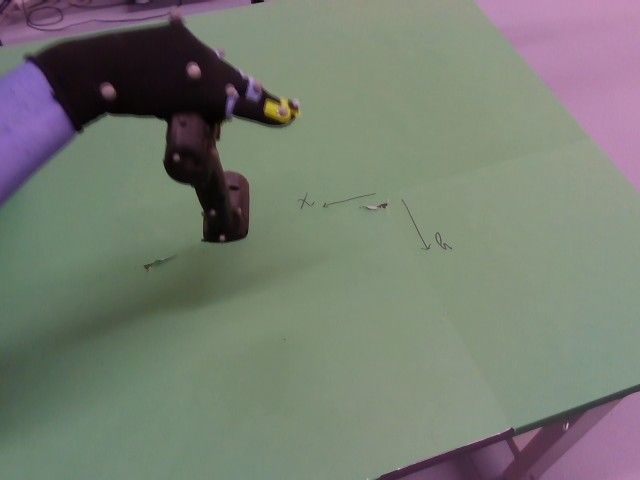

In [ ]:
# 创建控件

# Lance 轨迹选择下拉菜单（使用优化的加载器）
trajectory_dropdown = Dropdown(
    description='轨迹索引:',
    options=loader.create_trajectory_options(),
    value=TRAJECTORY_INDEX,
    layout=Layout(width='600px'),
    style={'description_width': '80px'}
)

# 帧滑块
frame_slider = IntSlider(
    description='帧:',
    min=0,
    max=T - 1,
    step=1,
    value=0,
    layout=Layout(width='600px'),
    continuous_update=False
)

# 摄像头选择
camera_dropdown = Dropdown(
    description='摄像头:',
    options=[(f"相机 {i}", i) for i in range(video_blobs['num_cameras'])],
    value=0,
    layout=Layout(width='200px')
)

# 视频流类型选择
stream_dropdown = Dropdown(
    description='视频流:',
    options=[('彩色', 'color'), ('深度', 'depth')],
    value='color',
    layout=Layout(width='200px')
)

# 3D 显示选项
show_mano_mesh_cb = Checkbox(value=True, description='MANO Mesh')
show_mano_joints_cb = Checkbox(value=True, description='MANO Joints')
show_urdf_joints_cb = Checkbox(value=True, description='URDF Joints')
show_urdf_mesh_cb = Checkbox(value=True, description='URDF Mesh')
show_object_cb = Checkbox(value=True, description='Object')
show_origin_cb = Checkbox(value=True, description='Origin')

# Curve 选择
curve_options = get_curve_options()
default_curves = ['mano.global_pos.x', 'mano.global_pos.y', 'mano.global_pos.z']
curves_select = SelectMultiple(
    options=curve_options,
    value=default_curves,
    description='曲线:',
    rows=10,
    layout=Layout(width='250px')
)

# 播放控制
play_button = Button(description='▶ 播放', button_style='success')
pause_button = Button(description='⏸ 暂停', button_style='warning')

# 轨迹信息显示
trajectory_info_html = WidgetHTML("")

# 输出区域
video_output = Output()
plot_output = Output()
curve_output = Output()

# 初始化 figure
fig = initialize_figure()
_is_playing = False

# 轨迹切换函数（使用优化的加载器）
def on_trajectory_change(change):
    """当轨迹选择改变时触发"""
    new_index = change['new']
    
    # 暂停播放
    global _is_playing
    _is_playing = False
    
    # 使用优化的重新加载函数
    if reload_trajectory_data(new_index):
        # 更新帧滑块范围
        frame_slider.max = T - 1
        frame_slider.value = 0
        
        # 更新摄像头选项
        camera_dropdown.options = [(f"相机 {i}", i) for i in range(video_blobs['num_cameras'])]
        camera_dropdown.value = 0
        
        # 更新曲线选项
        new_curve_options = get_curve_options()
        curves_select.options = new_curve_options
        curves_select.value = default_curves if len(default_curves) <= len(new_curve_options) else new_curve_options[:3]
        
        # 更新轨迹信息（使用缓存的信息）
        info = loader.get_trajectory_info(new_index)
        trajectory_info_html.value = f"<b>场景:</b> {info['scene']} | <b>操作员:</b> {info['operator']} | <b>帧数:</b> {info['frames']}"
        
        # 刷新可视化
        update_visualization()
    else:
        print(f"❌ 无法加载轨迹 {new_index}")

# 更新函数
def update_visualization(*args):
    # 更新 3D 可视化
    update_figure(
        fig,
        frame_slider.value,
        show_mano_mesh=show_mano_mesh_cb.value,
        show_mano_joints=show_mano_joints_cb.value,
        show_urdf_joints=show_urdf_joints_cb.value,
        show_urdf_mesh=show_urdf_mesh_cb.value,
        show_object=show_object_cb.value,
        show_origin=show_origin_cb.value
    )
    
    # 更新视频帧
    with video_output:
        video_output.clear_output(wait=True)
        frame = decode_video_frame(
            video_blobs,
            camera_dropdown.value,
            frame_slider.value,
            stream_dropdown.value
        )
        if frame is not None:
            img_data = frame_to_base64(frame)
            display(HTML(f'<img src="{img_data}" style="max-width:640px; height:auto;" />'))
        else:
            print("视频帧不可用")
    
    # 更新曲线图
    with curve_output:
        curve_output.clear_output(wait=True)
        
        selected_curves = curves_select.value
        if len(selected_curves) == 0:
            print("请选择至少一条曲线")
            return
        
        curve_fig = go.Figure()
        
        # 绘制选中的曲线
        for curve_name in selected_curves:
            data = get_curve_data(curve_name)
            if data is not None:
                curve_fig.add_trace(go.Scatter(
                    x=np.arange(len(data)),
                    y=data,
                    mode='lines',
                    name=curve_name,
                    line=dict(width=2)
                ))
                
                # 当前帧标记
                if frame_slider.value < len(data):
                    curve_fig.add_trace(go.Scatter(
                        x=[frame_slider.value],
                        y=[data[frame_slider.value]],
                        mode='markers',
                        marker=dict(size=10, color='red'),
                        showlegend=False,
                        hovertemplate=f'<b>{curve_name}</b><br>Frame: {frame_slider.value}<br>Value: {data[frame_slider.value]:.4f}<extra></extra>'
                    ))
        
        # 当前帧竖线
        curve_fig.add_vline(
            x=frame_slider.value,
            line_dash="dash",
            line_color="red",
            line_width=2,
            annotation_text=f"Frame {frame_slider.value}",
            annotation_position="top"
        )
        
        curve_fig.update_layout(
            title=f"Frame {frame_slider.value}/{T-1}",
            xaxis_title='Frame Index',
            yaxis_title='Value',
            height=300,
            template='plotly_dark',
            hovermode='closest',
            margin=dict(l=50, r=50, t=50, b=50)
        )
        
        display(HTML(pyo.plot(curve_fig, output_type='div', include_plotlyjs='cdn')))

# 播放控制
def play_animation(b):
    global _is_playing
    if _is_playing:
        return
    
    _is_playing = True
    import time
    import threading
    
    def animate():
        global _is_playing
        target_fps = 100
        frame_time = 1.0 / target_fps
        
        while _is_playing and frame_slider.value < frame_slider.max:
            start_time = time.time()
            frame_slider.value += 1
            elapsed = time.time() - start_time
            sleep_time = max(0, frame_time - elapsed)
            
            if sleep_time > 0:
                for _ in range(int(sleep_time * 100)):
                    if not _is_playing:
                        return
                    time.sleep(0.001)
        
        _is_playing = False
    
    thread = threading.Thread(target=animate)
    thread.daemon = True
    thread.start()

def pause_animation(b):
    global _is_playing
    _is_playing = False

# 绑定事件
trajectory_dropdown.observe(on_trajectory_change, names='value')
frame_slider.observe(update_visualization, 'value')
camera_dropdown.observe(update_visualization, 'value')
stream_dropdown.observe(update_visualization, 'value')
show_mano_mesh_cb.observe(update_visualization, 'value')
show_mano_joints_cb.observe(update_visualization, 'value')
show_urdf_joints_cb.observe(update_visualization, 'value')
show_urdf_mesh_cb.observe(update_visualization, 'value')
show_object_cb.observe(update_visualization, 'value')
show_origin_cb.observe(update_visualization, 'value')
curves_select.observe(update_visualization, 'value')
play_button.on_click(play_animation)
pause_button.on_click(pause_animation)

# 初始化轨迹信息（使用缓存）
info = loader.get_trajectory_info(TRAJECTORY_INDEX)
trajectory_info_html.value = f"<b>场景:</b> {info['scene']} | <b>操作员:</b> {info['operator']} | <b>帧数:</b> {info['frames']}"

print("✓ 优化的交互式界面已创建（使用高效的 Lance 数据加载）")
print(f"🚀 性能优化: 使用 take() 方法和缓存机制，避免加载整个数据集")

## 10. 启动可视化

In [11]:
# 组装界面
ui = VBox([
    WidgetHTML("<h2>Lance 数据集可视化 </h2>"),
    
    # 轨迹选择和信息显示
    VBox([
        WidgetHTML("<h3>📁 轨迹索引选择</h3>"),
        HBox([
            trajectory_dropdown,
            trajectory_info_html
        ])
    ]),
    
    WidgetHTML("<hr>"),
    
    # 控制面板
    HBox([
        VBox([
            WidgetHTML("<b>视频控制:</b>"),
            camera_dropdown,
            stream_dropdown
        ]),
        VBox([
            WidgetHTML("<b>显示选项:</b>"),
            show_mano_mesh_cb,
            show_mano_joints_cb,
            show_urdf_joints_cb,
            show_urdf_mesh_cb,
            show_object_cb,
            show_origin_cb
        ]),
        VBox([
            WidgetHTML("<b>曲线选择:</b>"),
            curves_select
        ]),
        VBox([
            WidgetHTML("<b>播放控制:</b>"),
            HBox([play_button, pause_button])
        ])
    ]),
    
    # 帧控制
    frame_slider,
    
    WidgetHTML("<hr>"),
    
    # 内容显示区域
    VBox([
        HBox([
            VBox([
                WidgetHTML("<h3>📹 视频流</h3>"),
                video_output
            ]),
            VBox([
                WidgetHTML("<h3>🎯 3D 可视化</h3>"),
                plot_output
            ])
        ]),
        VBox([
            WidgetHTML("<h3>📊 数据曲线</h3>"),
            curve_output
        ])
    ])
])

# 显示界面
display(ui)

# 显示 3D figure
with plot_output:
    display(fig)

# 初始更新
update_visualization()
